In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Load data
train_df = pd.read_csv(r'C:\Users\Rama\Desktop\SPRING-Junior\ANN\Kaggle\ann-spr-26-nu\multimodal_competition\processed\train.csv')
test_df = pd.read_csv(r'C:\Users\Rama\Desktop\SPRING-Junior\ANN\Kaggle\ann-spr-26-nu\multimodal_competition\processed\test.csv')


# Basic info
print("="*50)
print("TRAIN DATA")
print("="*50)
print(f"Shape: {train_df.shape}")
print(f"\nTarget distribution:\n{train_df['target_band'].value_counts().sort_index()}")
print(f"\nTarget percentages:\n{train_df ['target_band'].value_counts(normalize=True).sort_index() * 100}")

print("\n" + "="*50)
print("TEST DATA")
print("="*50)
print(f"Shape: {test_df.shape}")


TRAIN DATA
Shape: (8870, 19)

Target distribution:
target_band
0     314
1    2694
2    1218
3    2646
4    1998
Name: count, dtype: int64

Target percentages:
target_band
0     3.540023
1    30.372041
2    13.731680
3    29.830891
4    22.525366
Name: proportion, dtype: float64

TEST DATA
Shape: (3130, 18)


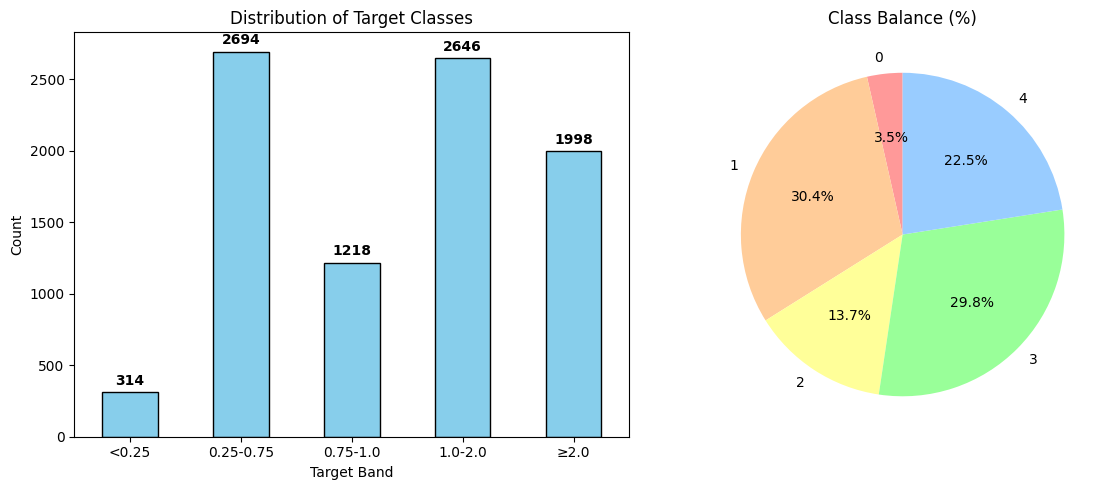


Class distribution statistics:
Mean: 2.37
Median: 3.0
Std: 1.23


In [3]:
# Target distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Class distribution
ax1 = axes[0]
train_df['target_band'].value_counts().sort_index().plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_xlabel('Target Band')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of Target Classes')
ax1.set_xticklabels(['<0.25', '0.25-0.75', '0.75-1.0', '1.0-2.0', '≥2.0'], rotation=0)

# Add count labels on bars
for i, v in enumerate(train_df['target_band'].value_counts().sort_index().values):
    ax1.text(i, v + 50, str(v), ha='center', fontweight='bold')

# Class balance percentage
ax2 = axes[1]
balance = train_df['target_band'].value_counts(normalize=True).sort_index() * 100
colors = ['#ff9999', '#ffcc99', '#ffff99', '#99ff99', '#99ccff']
balance.plot(kind='pie', ax=ax2, autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Class Balance (%)')

plt.tight_layout()
plt.show()

# Check for ordinal nature - class correlations
print("\nClass distribution statistics:")
print(f"Mean: {train_df['target_band'].mean():.2f}")
print(f"Median: {train_df['target_band'].median()}")
print(f"Std: {train_df['target_band'].std():.2f}")

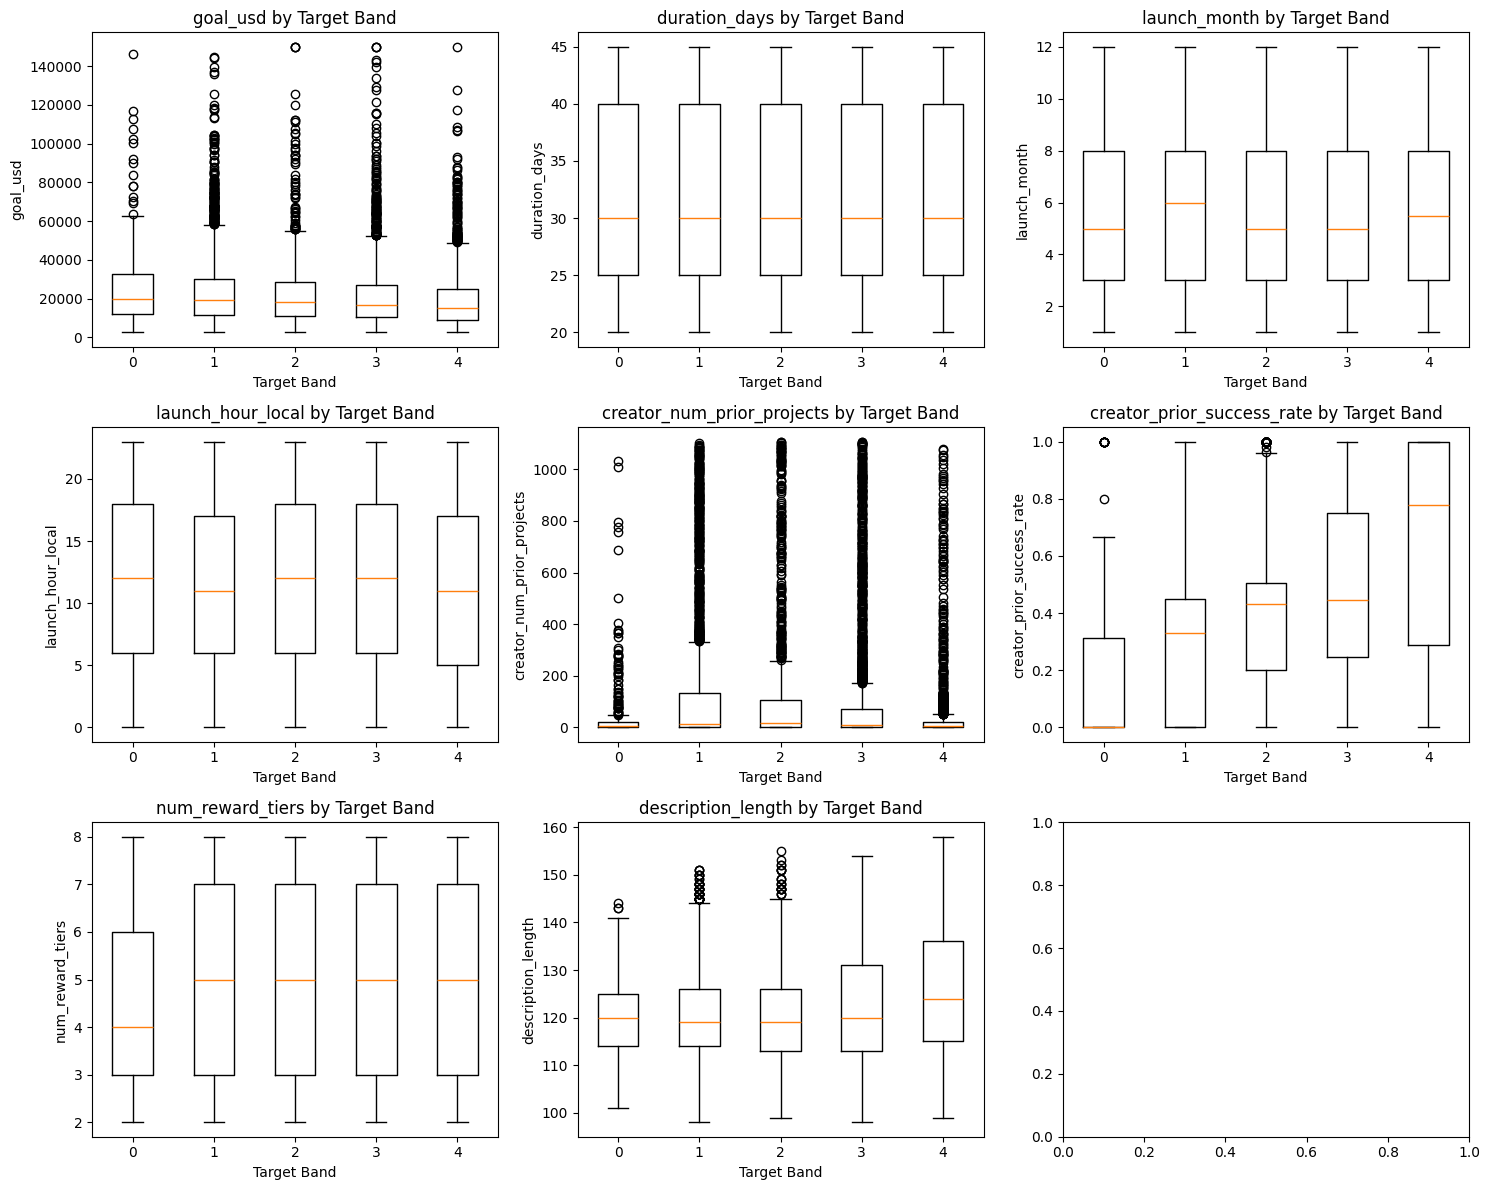


GOAL_USD
                 mean    median       std
target_band                              
0            25327.37  19536.12  20260.41
1            24172.88  19278.39  18395.22
2            22665.78  18279.56  18098.57
3            21424.76  16764.44  17378.16
4            19525.28  15112.05  15245.35

DURATION_DAYS
              mean  median   std
target_band                     
0            32.33    30.0  8.25
1            32.18    30.0  8.14
2            31.48    30.0  8.06
3            32.07    30.0  7.96
4            31.93    30.0  7.99

LAUNCH_MONTH
             mean  median   std
target_band                    
0            5.54     5.0  3.17
1            5.75     6.0  3.17
2            5.65     5.0  3.17
3            5.68     5.0  3.22
4            5.73     5.5  3.19

LAUNCH_HOUR_LOCAL
              mean  median   std
target_band                     
0            11.75    12.0  7.02
1            11.29    11.0  6.82
2            11.88    12.0  6.90
3            11.74    12.0  

In [4]:
# Separate features by type
numeric_features = ['goal_usd', 'duration_days', 'launch_month', 'launch_hour_local', 
                    'creator_num_prior_projects', 'creator_prior_success_rate', 
                    'num_reward_tiers', 'description_length']
categorical_features = ['category_main', 'category_sub', 'country', 'currency', 
                        'launch_weekday', 'has_video']



# Numeric features analysis
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(numeric_features):
    if idx < len(axes):
        ax = axes[idx]
        # Boxplot by target class
        for target in range(5):
            data = train_df[train_df['target_band'] == target][col].dropna()
            if len(data) > 0:
                ax.boxplot([train_df[train_df['target_band'] == t][col].dropna() for t in range(5)], 
                          positions=range(5), labels=['0','1','2','3','4'])
                ax.set_title(f'{col} by Target Band')
                ax.set_xlabel('Target Band')
                ax.set_ylabel(col)
                break  # Only create one plot per feature

plt.tight_layout()
plt.show()

# Summary statistics by target
for col in numeric_features:
    print(f"\n{col.upper()}")
    print(train_df.groupby('target_band')[col].agg(['mean', 'median', 'std']).round(2))

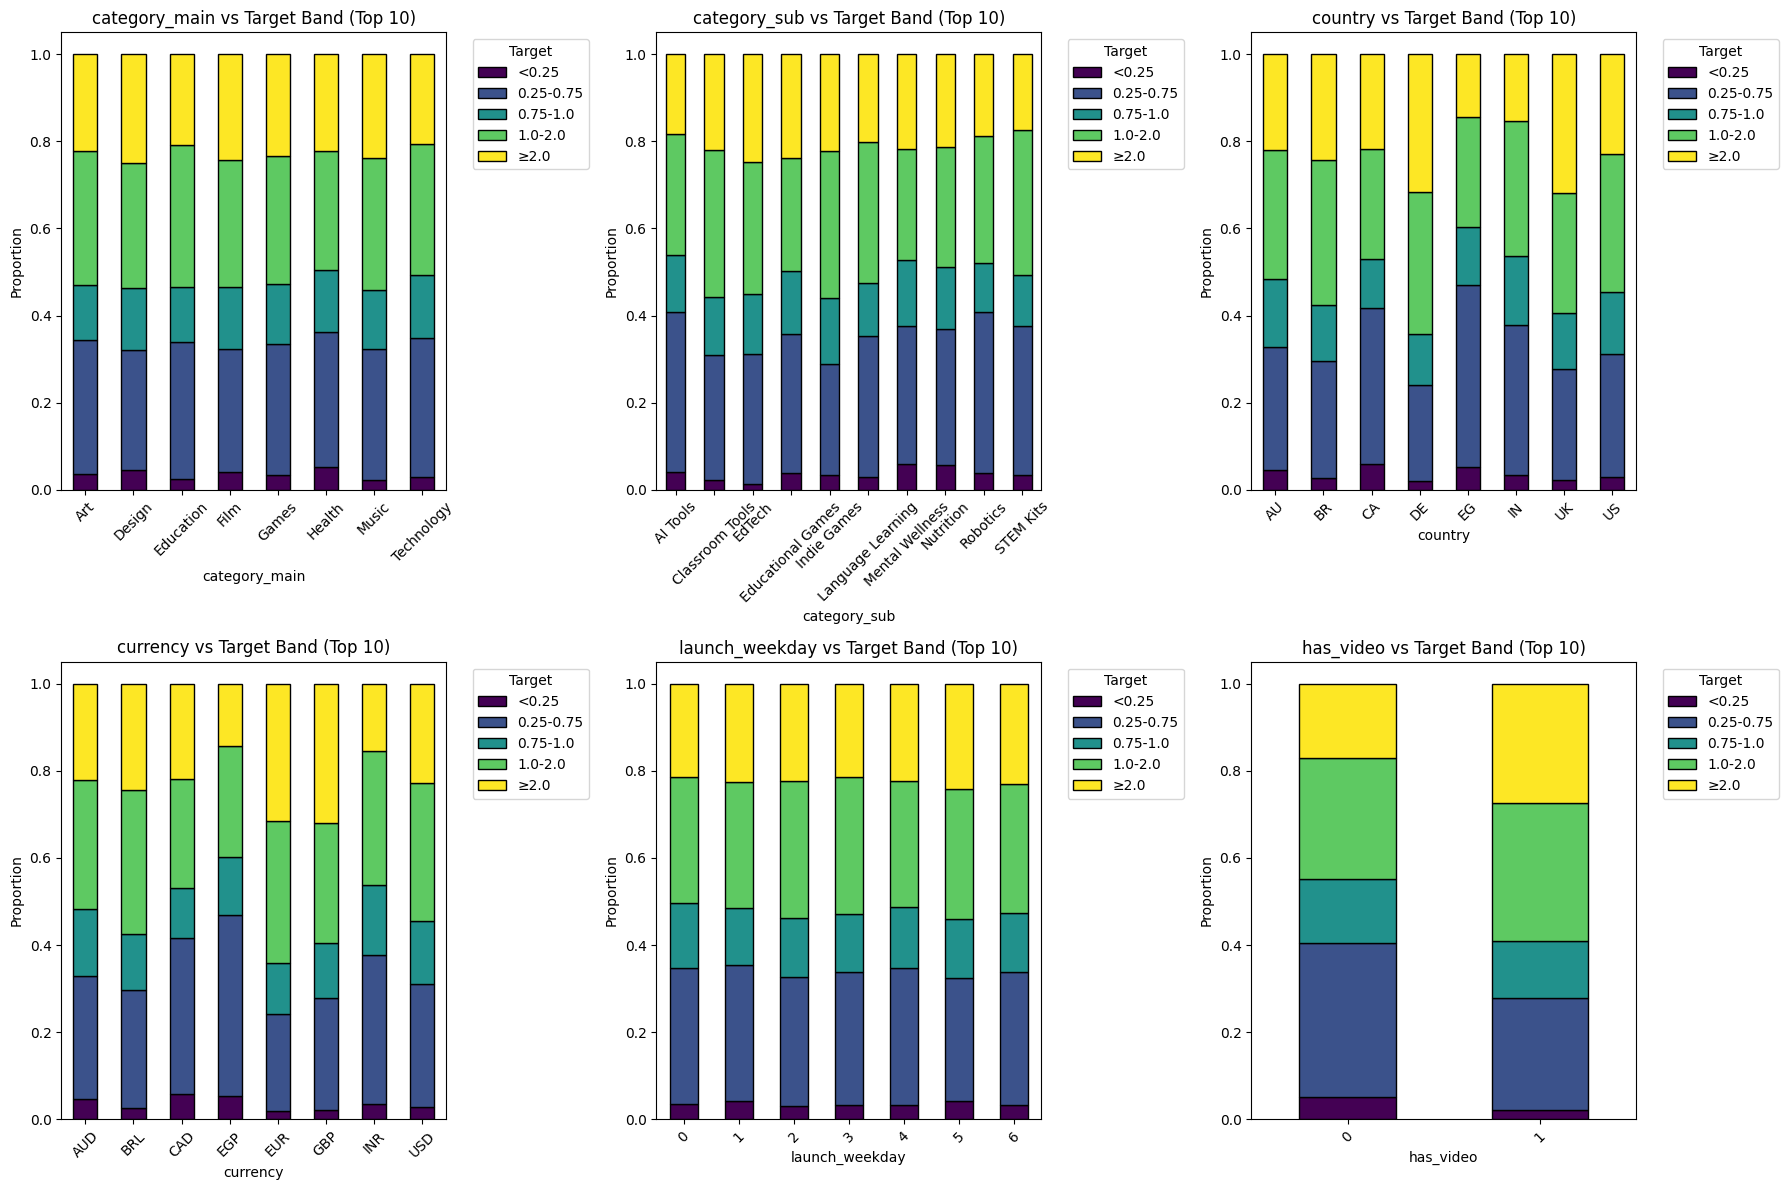

category_main        - Chi2 p-value: 1.3798e-02 (Significant)
category_sub         - Chi2 p-value: 7.8476e-02 (Not significant)
country              - Chi2 p-value: 1.3668e-42 (Significant)
currency             - Chi2 p-value: 1.3668e-42 (Significant)
launch_weekday       - Chi2 p-value: 8.8772e-01 (Not significant)
has_video            - Chi2 p-value: 2.7706e-51 (Significant)


In [6]:
# Categorical features analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(categorical_features):
    if idx < len(axes):
        ax = axes[idx]
        
        # Get top 10 categories
        top_cats = train_df[col].value_counts().head(10).index
        plot_data = train_df[train_df[col].isin(top_cats)]
        
        # Create crosstab
        ct = pd.crosstab(plot_data[col], plot_data['target_band'], normalize='index')
        ct.plot(kind='bar', stacked=True, ax=ax, colormap='viridis', edgecolor='black')
        ax.set_title(f'{col} vs Target Band (Top 10)')
        ax.set_xlabel(col)
        ax.set_ylabel('Proportion')
        ax.legend(title='Target', bbox_to_anchor=(1.05, 1), labels=['<0.25','0.25-0.75','0.75-1.0','1.0-2.0','≥2.0'])
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Chi-square tests for categorical features
from scipy.stats import chi2_contingency

for col in categorical_features:
    contingency = pd.crosstab(train_df[col], train_df['target_band'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"{col:20} - Chi2 p-value: {p:.4e} {'(Significant)' if p < 0.05 else '(Not significant)'}")

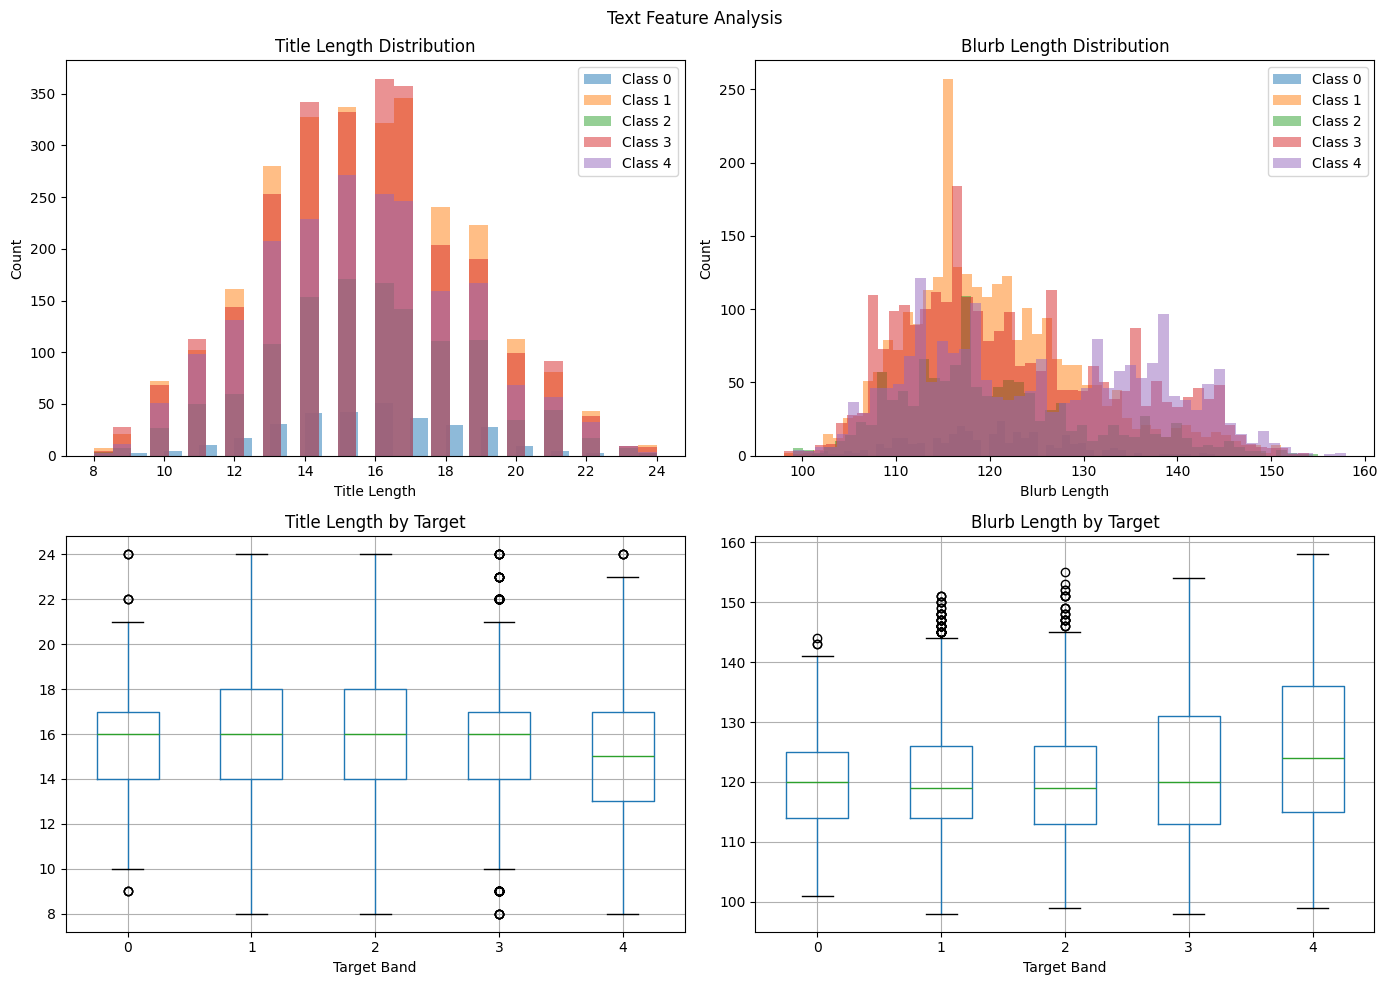

Top words in HIGH performing campaigns:
  project: 2025
  that: 1998
  and: 1358
  with: 1064
  practical: 582
  value: 579
  campaign: 447
  minimal: 402
  concept: 368
  launch: 359
  design: 356
  product: 315
  built: 311
  careful: 311
  attention: 311

Top words in LOW performing campaigns:
  project: 317
  that: 314
  and: 218
  with: 194
  minimal: 120
  concept: 114
  launch: 92
  campaign: 91
  short: 82
  experimental: 80
  ambitious: 79
  limited: 79
  validation: 79
  rough: 79
  messaging: 79


In [7]:
import re
from collections import Counter

# Text length analysis
train_df['title_len'] = train_df['title'].str.len()
train_df['blurb_len'] = train_df['blurb'].str.len()
train_df['total_text_len'] = train_df['title_len'] + train_df['blurb_len']
train_df['title_words'] = train_df['title'].str.split().str.len()
train_df['blurb_words'] = train_df['blurb'].str.split().str.len()

# Word count analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Title length by target
for target in range(5):
    axes[0,0].hist(train_df[train_df['target_band'] == target]['title_len'].dropna(), 
                   bins=30, alpha=0.5, label=f'Class {target}')
axes[0,0].set_xlabel('Title Length')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Title Length Distribution')
axes[0,0].legend()

# Blurb length by target
for target in range(5):
    axes[0,1].hist(train_df[train_df['target_band'] == target]['blurb_len'].dropna().clip(upper=500), 
                   bins=50, alpha=0.5, label=f'Class {target}')
axes[0,1].set_xlabel('Blurb Length')
axes[0,1].set_ylabel('Count')
axes[0,1].set_title('Blurb Length Distribution')
axes[0,1].legend()

# Boxplots
train_df.boxplot(column='title_len', by='target_band', ax=axes[1,0])
axes[1,0].set_title('Title Length by Target')
axes[1,0].set_xlabel('Target Band')

train_df.boxplot(column='blurb_len', by='target_band', ax=axes[1,1])
axes[1,1].set_title('Blurb Length by Target')
axes[1,1].set_xlabel('Target Band')

plt.suptitle('Text Feature Analysis')
plt.tight_layout()
plt.show()

# Word frequency analysis for high vs low performing campaigns
def get_top_words(texts, n=20):
    all_words = ' '.join(texts.dropna().str.lower())
    words = re.findall(r'\b[a-z]{3,}\b', all_words)
    return Counter(words).most_common(n)

# Compare high performers (class 4) vs low performers (class 0)
high_perf_text = train_df[train_df['target_band'] == 4]['title'] + ' ' + train_df[train_df['target_band'] == 4]['blurb']
low_perf_text = train_df[train_df['target_band'] == 0]['title'] + ' ' + train_df[train_df['target_band'] == 0]['blurb']

print("Top words in HIGH performing campaigns:")
for word, count in get_top_words(high_perf_text)[:15]:
    print(f"  {word}: {count}")

print("\nTop words in LOW performing campaigns:")
for word, count in get_top_words(low_perf_text)[:15]:
    print(f"  {word}: {count}")

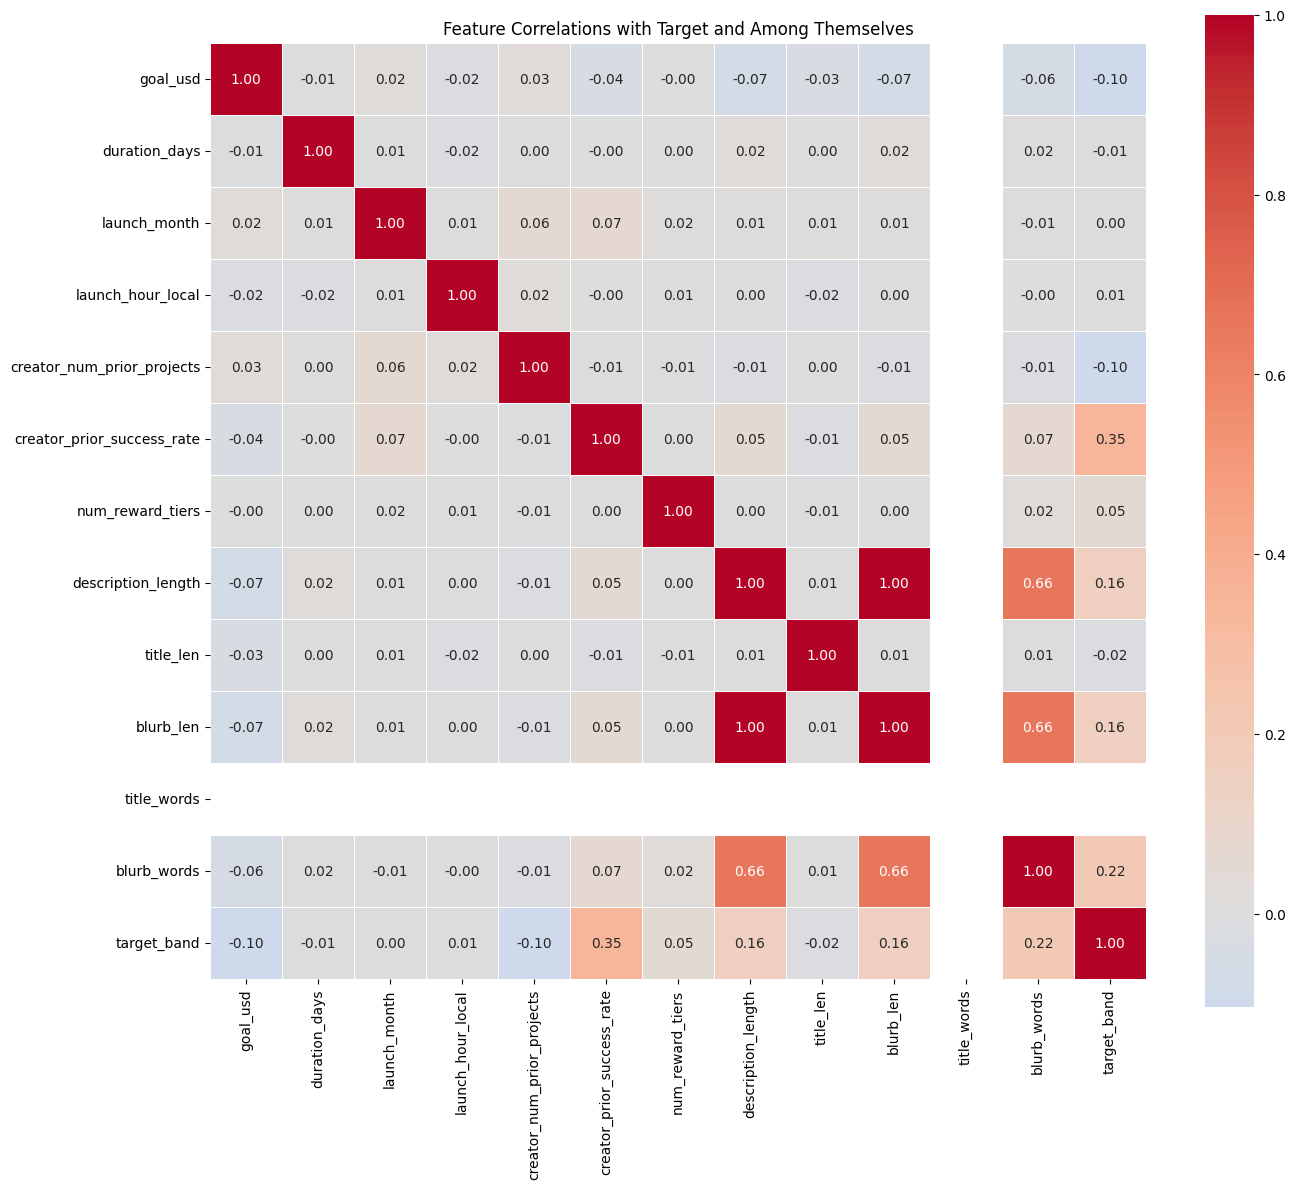


Top features correlated with target:
  creator_prior_success_rate: 0.352
  blurb_words: 0.219
  description_length: 0.163
  blurb_len: 0.163
  num_reward_tiers: 0.051
  creator_num_prior_projects: -0.100
  goal_usd: -0.104


In [8]:
# Correlation matrix for numeric features
numeric_cols_for_corr = numeric_features + ['title_len', 'blurb_len', 'title_words', 'blurb_words']

corr_matrix = train_df[numeric_cols_for_corr + ['target_band']].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Feature Correlations with Target and Among Themselves')
plt.tight_layout()
plt.show()

# Print top correlations with target
target_corr = corr_matrix['target_band'].sort_values(ascending=False)
print("\nTop features correlated with target:")
for feat, corr in target_corr.items():
    if feat != 'target_band' and abs(corr) > 0.05:
        print(f"  {feat}: {corr:.3f}")